In [11]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os 

In [12]:
load_dotenv()



api_key = os.getenv("GROQ_API_KEY")

llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=api_key
)


In [13]:
def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}
    

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

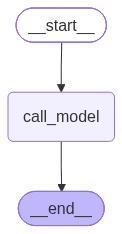

In [15]:
graph = builder.compile()
graph

In [16]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Rana."}]})


{'messages': [HumanMessage(content='Hi! My name is Rana.', additional_kwargs={}, response_metadata={}, id='35fa02f6-1643-4485-afa0-eee9f564a707'),
  AIMessage(content='Hi Rana! 👋 Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 78, 'total_tokens': 125, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 21, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.322290365, 'prompt_time': 0.002903824, 'completion_time': 0.098646992, 'total_time': 0.101550816}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_fe269835c7', 'id': 'chatcmpl-c44fbdeb-e53e-4888-ad0b-10bad719195a', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03f9f-4a2c-70f3-a17d-3d36a1751861-0', tool_calls=[], invalid_tool_calls=[

In [17]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]})


{'messages': [HumanMessage(content='What is my name?', additional_kwargs={}, response_metadata={}, id='9cda9347-cbdf-4174-b049-e98e0bf35ed8'),
  AIMessage(content='I’m not sure what your name is—unless you’ve shared it with me earlier in our conversation, I don’t have that information. If you’d like me to address you by name, just let me know what you’d prefer!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 155, 'prompt_tokens': 76, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 98, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.291827872, 'prompt_time': 0.003007848, 'completion_time': 0.325026554, 'total_time': 0.328034402}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5781dfb07c', 'id': 'chatcmpl-c9d910ea-4d68-494a-9e92-fc77d41d57bb', 'service_tier': 'on

In [28]:
def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [29]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

In [30]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


graph = builder.compile(checkpointer=checkpointer)


In [26]:
config = {"configurable": {"thread_id": "thread-1"}}
config2 = {"configurable": {"thread_id": "thread-2"}}

In [31]:
graph.invoke({"messages": [{"role": "user", "content": "Hi! My name is Rana."}]}, config)


{'messages': [HumanMessage(content='Hi! My name is Rana.', additional_kwargs={}, response_metadata={}, id='890b12d0-d5cf-4a42-b568-8910a8a0a83e'),
  AIMessage(content='Hello, Rana! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 78, 'total_tokens': 142, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 37, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.05406087, 'prompt_time': 0.00286091, 'completion_time': 0.135235434, 'total_time': 0.138096344}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'id': 'chatcmpl-0ed75836-e4b7-4440-bceb-106653ad93d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03fa2-9f9a-7312-8af8-30887895e77e-0', tool_calls=[], invalid_tool_cal

In [33]:
graph.invoke({"messages": [{"role": "user", "content": "What is my name?"}]}, config)


{'messages': [HumanMessage(content='Hi! My name is Rana.', additional_kwargs={}, response_metadata={}, id='890b12d0-d5cf-4a42-b568-8910a8a0a83e'),
  AIMessage(content='Hello, Rana! 👋 Nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 78, 'total_tokens': 142, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 37, 'rejected_prediction_tokens': None, 'text_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.05406087, 'prompt_time': 0.00286091, 'completion_time': 0.135235434, 'total_time': 0.138096344}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'id': 'chatcmpl-0ed75836-e4b7-4440-bceb-106653ad93d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a03fa2-9f9a-7312-8af8-30887895e77e-0', tool_calls=[], invalid_tool_cal

In [34]:

snap = graph.get_state(config)
vals = snap.values
for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content)

- HumanMessage : Hi! My name is Rana.
- AIMessage : Hello, Rana! 👋 Nice to meet you. How can I assist you today?
- HumanMessage : What is my name?
- AIMessage : Your name is Rana.
